# 📊 Regresión: Comparación de Modelos y Selección del Mejor
**Curso de Data Science & Machine Learning**  
Dataset: Diabetes (sklearn) — predicción de progresión de la enfermedad

---
## Índice
1. Setup y carga de datos
2. EDA sencillo
3. Selección de características
4. Split train / test
5. Entrenamiento de modelos
6. Evaluación por métricas
7. Comparación por velocidad
8. Guardar el modelo ganador y usarlo con nuevos datos

---
## 1. Setup y carga de datos

In [26]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Librerías listas")

✅ Librerías listas


In [27]:
# Cargar el dataset directamente desde sklearn
# as_frame=True devuelve un DataFrame en lugar de arrays numpy
datos = load_diabetes(as_frame=True)

df = datos.frame  # DataFrame completo: features + target

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nDescripción del target:")
print(datos.DESCR)

Shape: (442, 11)

Columnas: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Descripción del target:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, po

**Descripción de variables:**

| Variable | Descripción |
|---|---|
| age | Edad |
| sex | Sexo (codificado) |
| bmi | Índice de masa corporal |
| bp | Presión arterial promedio |
| s1–s6 | Mediciones séricas (colesterol, glucosa, etc.) |
| **target** | **Progresión de la enfermedad (variable a predecir)** |

---
## 2. EDA Sencillo

In [28]:
# Vista general del dataset
# Inserta código acá
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [29]:
# Estadísticas descriptivas
# Inserta código acá
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


In [30]:
# Verificar valores nulos
# Inserta código acá

df.isna().sum()
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='target', ylabel='Count'>

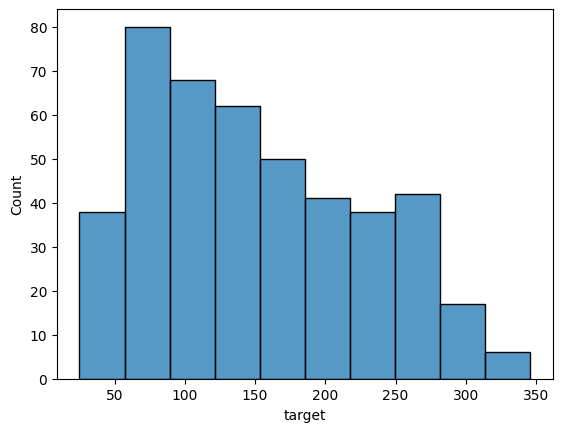

In [31]:
# Distribución del target
# Inserta código acá

sns.histplot(df['target']) #Es importante revisar la distribución del target para poder visualizar si hay datos atipicos o si el target está desbalanceado. Esto nos puede ayudar a decidir qué modelo usar o si es necesario hacer algún tipo de transformación al target.

In [32]:
# Correlación de cada feature con el target
# Esto nos da una idea rápida de cuáles variables son más relevantes, es decir que tienen una relación más fuerte con el target.

correlaciones = df.corr()['target'].sort_values(ascending = False) #se coloca el [target] para mostrar la correlacion con el target y sort_values para ordenar de mayor a menor.
print(correlaciones)
# Inserta código acá)


target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


---
## 3. Selección de Características

### ¿Por qué no basta con tomar las más correlacionadas con el target?

Seleccionar features solo por su correlación con el target tiene un problema: **dos features pueden estar altamente correlacionadas entre sí**, es decir, medir casi lo mismo. Incluir ambas no le da información nueva al modelo — solo ruido y redundancia.

Esto se llama **multicolinealidad** y tiene consecuencias concretas:

| Modelo | Efecto de la multicolinealidad |
|---|---|
| Regresión Lineal | Los coeficientes se vuelven inestables e ininterpretables |
| Árbol / Random Forest | Menor impacto, pero se introduce ruido innecesario |

**Solución simple:** antes de seleccionar features, revisar la **correlación entre ellas** y descartar una de cada par con correlación alta (umbral típico: > 0.85 en valor absoluto).

<Axes: >

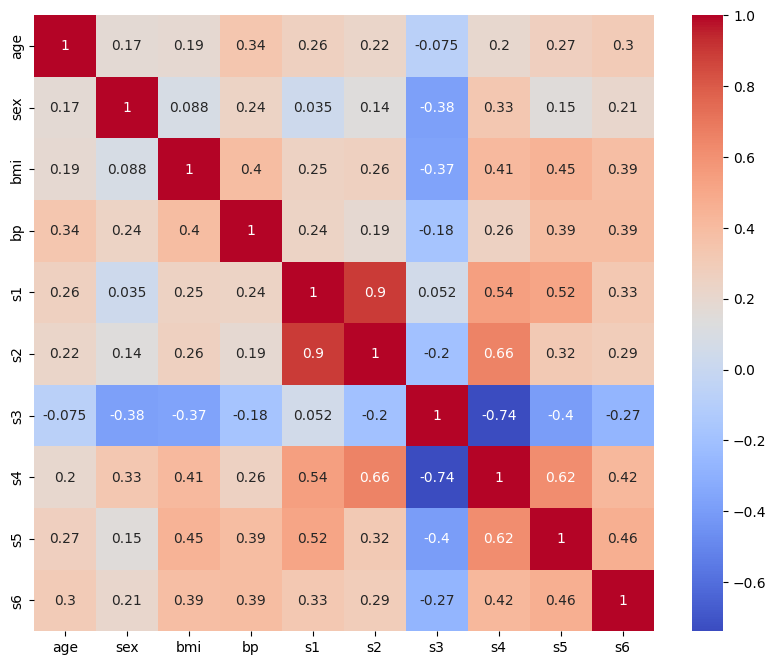

In [33]:
# Heatmap de correlación ENTRE features (excluimos el target)
features_candidatas = df.drop(columns='target')
plt.figure(figsize=(10,8))
sns.heatmap(features_candidatas.corr(), annot=True, cmap='coolwarm')

#Recuerda que estamos revisando las variables que estan DEMASIADO correlacionadas entre si. En este caso s2 y s1 tienen una correlacion de .90; entonces en el analisis escogemos una de esas variables.Mismo caso en s4 con s2 


In [36]:
# Selección de features: alta correlación con el target + baja entre sí
#
# Algoritmo greedy (paso a paso):
#   1. Ordenar candidatas por correlación absoluta con el target (de mayor a menor)
#   2. Agregar la siguiente candidata SOLO si no está muy correlacionada
#      con ninguna de las ya seleccionadas (umbral = 0.85)
#   3. Parar cuando tengamos 5 features

UMBRAL_MULTI = 0.70   # correlación máxima permitida entre features
N_FEATURES   = 5  #Este es el número de features que queremos seleccionar.


correlaciones = df.corr()['target'].drop('target').sort_values(ascending=False) #Ordenamos las correlaciones de mayor a menor, pero sin incluir el target.
candidatas_ordenadas = correlaciones.abs().sort_values(ascending=False).index.tolist()
corr_matrix = features_candidatas.corr()

# Inserta código acá

seleccionadas= []

for caracteristica in candidatas_ordenadas:
    if caracteristica == 'target': # Ignoramos el target
        continue
    if len(seleccionadas) >= N_FEATURES: # Si ya tenemos 5 features, paramos el proceso
        break
    
    demasiado_correlacionada = any(
        abs(corr_matrix.loc[caracteristica, ya_sel]) > UMBRAL_MULTI
        for ya_sel in seleccionadas
    )
    if not demasiado_correlacionada:
        seleccionadas.append(caracteristica)

print(seleccionadas)

['bmi', 's5', 'bp', 's4', 's6']


---
## 4. Split Train / Test

Dividimos **antes** de entrenar cualquier modelo.  
El set de test simula datos que el modelo nunca ha visto.

In [37]:
# Obtención de X y y para el modelado
# Inserta código acá

X = df[seleccionadas]
y= df['target']

In [38]:
# División en train y test
# Inserta código acá

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---
## 5. Entrenamiento de Modelos

Entrenamos **3 modelos de regresión** con parámetros simples.

In [42]:
# Definimos los modelos
modelos = {
    'Regresión Lineal':    LinearRegression(),
    'Árbol de Decisión':   DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
}

# Entrenamos cada uno y guardamos predicciones + tiempos
# Almacena los resultaddos, incluyendo el modelo, las predicciones y los tiempos en un diccionario para compararlos fácilmente


# Inserta código acá

#modelo_prueba = LinearRegression()
#modelo_prueba.fit(X_train, y_train)

#y_pred_train = modelo_prueba.predict(X_train)
#y_pred_test = modelo_prueba.predict(X_test)

#r2 = r2_score(y_test, y_pred_test)
#print(f"R² en test: {r2:.3f}")

resultados = {}
for nombre, modelo in modelos.items():
    #tiempo de entrenamiento
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t_train = time.time() - t0
    
    #predicciones train y test
    y_pred_train = modelo.predict(X_train)
    
    t0 = time.time()
    y_pred_test = modelo.predict(X_test)
    t_predict = (time.time() - t0) * 1000 #ms
    
    resultados[nombre] = {
        'modelo': modelo,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        't_train_s': t_train,
        't_predict_ms': t_predict,
    }

print('✅ Todos los modelos entrenados')

✅ Todos los modelos entrenados


---
## 6. Evaluación por Métricas

Para regresión usamos tres métricas clave:

| Métrica | ¿Qué mide? | ¿Mejor cuando es...? |
|---|---|---|
| **MAE** | Error absoluto promedio (mismas unidades del target) | Más bajo |
| **RMSE** | Raíz del error cuadrático (penaliza errores grandes) | Más bajo |
| **R²** | % de varianza explicada por el modelo | Más alto (máx = 1.0) |

In [44]:
def calcular_metricas(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Tabla comparativa: métricas en TRAIN y TEST
print(f"{'Modelo':<22} {'MAE Train':>10} {'MAE Test':>10} {'RMSE Train':>11} {'RMSE Test':>10} {'R² Train':>9} {'R² Test':>9}")
print('─' * 85)

for nombre, r in resultados.items():
    mae_tr, rmse_tr, r2_tr = calcular_metricas(y_train, r['y_pred_train'])
    mae_te, rmse_te, r2_te = calcular_metricas(y_test,  r['y_pred_test'])
    print(f"{nombre:<22} {mae_tr:>10.1f} {mae_te:>10.1f} {rmse_tr:>11.1f} {rmse_te:>10.1f} {r2_tr:>9.3f} {r2_te:>9.3f}")

#En este caso la regresion lineal es el mejor modelo, ya que tanto en train y test el modelo se ve bastante bueno. Los otros muestran signos de overfitting porque tienen valores altos en train pero no es test.

Modelo                  MAE Train   MAE Test  RMSE Train  RMSE Test  R² Train   R² Test
─────────────────────────────────────────────────────────────────────────────────────
Regresión Lineal             46.3       44.3        55.9       53.8     0.485     0.453
Árbol de Decisión            37.2       45.2        47.5       58.5     0.629     0.353
Random Forest                18.1       45.3        22.3       55.2     0.918     0.425


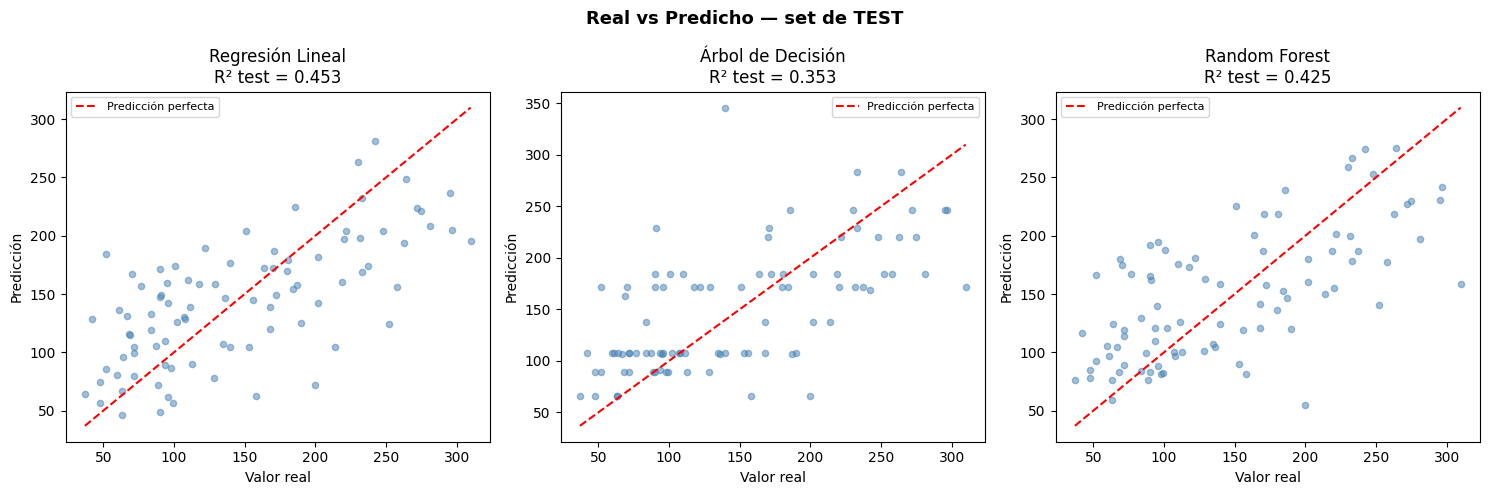

In [45]:
# Visualizar predicciones vs valores reales para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nombre, r) in zip(axes, resultados.items()):
    y_pred = r['y_pred_test']
    _, _, r2 = calcular_metricas(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)

    # Línea perfecta (predicción ideal)
    lim = [y_test.min(), y_test.max()]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')

    ax.set_xlabel('Valor real')
    ax.set_ylabel('Predicción')
    ax.set_title(f'{nombre}\nR² test = {r2:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Real vs Predicho — set de TEST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

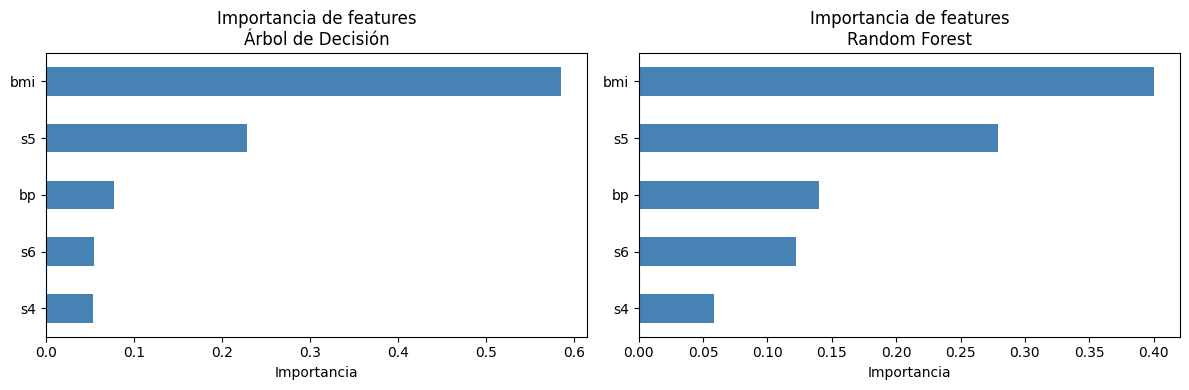

In [55]:
# Importancia de features (solo para los modelos basados en árboles)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, nombre in zip(axes, ['Árbol de Decisión', 'Random Forest']):
    modelo = resultados[nombre]['modelo']
    importancias = pd.Series(modelo.feature_importances_, index=seleccionadas).sort_values()
    importancias.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Importancia de features\n{nombre}')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.show()

---
## 7. Comparación por Velocidad

En producción no solo importa qué tan preciso es el modelo,  
sino también **qué tan rápido entrena y predice**.

In [56]:
print(f"{'Modelo':<22} {'Tiempo train':>14} {'Tiempo predict':>16}")
print('─' * 55)

for nombre, r in resultados.items():
    print(f"{nombre:<22} {r['t_train_s']:>12.4f}s {r['t_predict_ms']:>14.2f}ms")

Modelo                   Tiempo train   Tiempo predict
───────────────────────────────────────────────────────
Regresión Lineal             0.0032s           2.57ms
Árbol de Decisión            0.0045s           1.54ms
Random Forest                0.2099s          11.20ms


---
## 8. Guardar el Modelo Ganador y Usarlo con Nuevos Datos

Elegimos el modelo con mejor **R² en test** como ganador.  
Lo guardamos con `joblib` para reutilizarlo sin volver a entrenar.

In [57]:
modelo_ganador = resultados['Regresión Lineal']['modelo']
print(modelo_ganador)

LinearRegression()


In [ ]:
# Guardar el modelo ganador en disco
joblib.dump(modelo_ganador, 'modelo_diabetes_ganador.joblib') #joblib es una libreria que nos permite guardar modelos de machine learning en disco para poder usarlos posteriormente sin necesidad de volver a entrenarlos. En este caso estamos guardando el modelo ganador, que es la regresion lineal, en un archivo llamado 'modelo_diabetes_ganador.joblib'.

import os
size_kb = os.path.getsize('modelo_diabetes_ganador.joblib') / 1024
print(f"✅ Modelo guardado: 'modelo_diabetes_ganador.joblib' ({size_kb:.1f} KB)")

✅ Modelo guardado: 'modelo_diabetes_ganador.joblib' (0.9 KB)


In [60]:
# Simular producción: cargar el modelo y predecir sobre datos nuevos
modelo_produccion = joblib.load('modelo_diabetes_ganador.joblib')

# Datos de 4 pacientes nuevos (en el mismo orden que top_features)
# Recuerda: el modelo espera las mismas columnas con las que fue entrenado
nuevos_pacientes = pd.DataFrame({
    feat: [0.05, -0.01, 0.08, -0.03]
    for feat in seleccionadas
})

print(nuevos_pacientes)
# Sobreescribimos con valores más realistas para ilustrar variedad
nuevos_pacientes.iloc[0] = [ 0.06,  0.05,  0.07,  0.04,  0.01][:len(seleccionadas)]
nuevos_pacientes.iloc[1] = [-0.05, -0.04, -0.03, -0.02, -0.01][:len(seleccionadas)]
nuevos_pacientes.iloc[2] = [ 0.02,  0.01,  0.03,  0.00,  0.02][:len(seleccionadas)]
nuevos_pacientes.iloc[3] = [ 0.08,  0.07,  0.09,  0.06,  0.05][:len(seleccionadas)]

predicciones_nuevas = modelo_produccion.predict(nuevos_pacientes)

print(f"\n{'Paciente':<12} {'Progresión predicha':>20}")
print('─' * 35)
for i, pred in enumerate(predicciones_nuevas):
    print(f"Paciente {i+1:<4} {pred:>20.1f}")

    bmi    s5    bp    s4    s6
0  0.05  0.05  0.05  0.05  0.05
1 -0.01 -0.01 -0.01 -0.01 -0.01
2  0.08  0.08  0.08  0.08  0.08
3 -0.03 -0.03 -0.03 -0.03 -0.03

Paciente      Progresión predicha
───────────────────────────────────
Paciente 1                   234.6
Paciente 2                    92.4
Paciente 3                   177.8
Paciente 4                   264.6


---
## ✅ Resumen de esta clase

| Paso | ¿Qué hicimos? |
|---|---|
| EDA | Distribución del target, correlaciones, scatter plots |
| Selección de features | Top 5 por correlación con target, descartando multicolinealidad (umbral 0.85) |
| Split | 80% train / 20% test con `train_test_split` |
| Modelos | Regresión Lineal, Árbol de Decisión, Random Forest |
| Métricas | MAE, RMSE y R² — comparados en train Y test |
| Velocidad | Tiempo de `.fit()` y `.predict()` por modelo |
| Producción | `joblib.dump` para guardar, `joblib.load` para reutilizar |

**Próximo sprint:** escalado de features, búsqueda de hiperparámetros con `GridSearchCV`.